In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import missingno as msno
from collections import Counter
import unicodedata
import warnings
from nameparser import HumanName

warnings.filterwarnings('ignore')

file_path = 'wikidata9.csv'
output = 'wikidata18.csv'
df = pd.read_csv(file_path)

print(f"Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dataset carregado com 7484137 linhas e 19 colunas.


,id,nome,genero_P21,nacionalidade_P27,nome_nascimento_P1477,sobrenome_P734,nome_P735,nascimento_data_P569,morte_data_P570,local_nascimento_P19,pai_P22,mae_P25,irmaos_P3373,conjugue_P26,filhos_P40,parente_P1038,ocupacao_P106,residencia_P551,email_P968
0,Q23,George Washington,male,Kingdom of Great Britain;United States,NaN,Washington,George,1732-02-22T00:00:00Z,1799-12-14T00:00:00Z,Westmoreland County,Q768342,Q458119,Q850421;Q7412891;Q6219733;Q5083373;Q75764188;Q...,Q191789,NaN,Q21004273;Q1701323;Q1508559,politician;farmer;cartographer;geometer;engine...,Philadelphia;Westmoreland County;New York City...,NaN
1,Q42,Douglas Adams,male,United Kingdom,Douglas Noël Adams,Adams,Douglas;Noël,1952-03-11T00:00:00Z,2001-05-11T00:00:00Z,Cambridge,Q14623675,Q14623678,Q14623673,Q14623681,Q14623683,NaN,playwright;screenwriter;novelist;children's wr...,Cambridge;London;Brentwood;Santa Barbara,NaN
2,Q1868,Paul Otlet,male,Belgium,Paul Marie Ghislain Otlet,Otlet,Paul,1868-08-23T00:00:00Z,1944-12-10T00:00:00Z,City of Brussels,Q3579983,NaN,Q55824549,NaN,NaN,NaN,writer;lawyer;librarian;information scientist;...,Hôtel Otlet,NaN
3,Q207,George W. Bush,male,United States,George Walker Bush,Bush,George;Walker,1946-07-06T00:00:00Z,NaN,New Haven,Q23505,Q190628,Q3305438;Q1375345;Q221997;Q320829;Q52159104,Q152019,Q153730;Q153481,NaN,politician;motivational speaker;autobiographer...,Dallas;George W. Bush Childhood Home,NaN
4,Q297,Diego Velázquez,male,Spain,Diego Rodríguez de Silva y Velázquez,Rodríguez,Diego,1599-06-06T00:00:00Z,1660-08-06T00:00:00Z,Seville,Q21198367,Q21198368,NaN,Q22340307,Q105748660,NaN,painter;artist;visual artist,NaN,NaN


In [2]:
def definir_nome_principal(row):
    # regra 1: nome_nascimento_P1477
    if pd.notna(row.get('nome_nascimento_P1477')):
        nome_nasc = str(row['nome_nascimento_P1477']).strip()
        if len(nome_nasc.split()) > 1:
            return nome_nasc
            
    # regra 2: nome_P735 + sobrenome_P734
    nome_p = str(row.get('nome_P735', '')).replace(';', ' ').strip()
    sobrenome_p = str(row.get('sobrenome_P734', '')).replace(';', ' ').strip()
    
    if nome_p == 'nan': nome_p = ''
    if sobrenome_p == 'nan': sobrenome_p = ''
    
    nome_composto = f"{nome_p} {sobrenome_p}".strip()
    if len(nome_composto.split()) > 1:
        return nome_composto

    return str(row['nome']).strip() # fallback para coluna nome original

print("Aplicando lógica de prioridade de nomes...")
df['nome_processado'] = df.apply(definir_nome_principal, axis=1)

df['nome'] = df['nome_processado']
print("Nomes atualizados.")
df[['id', 'nome']].head()

Aplicando lógica de prioridade de nomes...
Nomes atualizados.


,id,nome
0,Q23,George Washington
1,Q42,Douglas Noël Adams
2,Q1868,Paul Marie Ghislain Otlet
3,Q207,George Walker Bush
4,Q297,Diego Rodríguez de Silva y Velázquez


In [3]:
print(f"Total de nomes inicialmente: {len(df)}")

def limpar_nome(nome):
    if pd.isna(nome): return np.nan
    nome = str(nome)
    
    # remover romanos
    romanos = r'\b(X{1,3}|X{0,3}(?:IX|IV|V|V?I{1,3}))\b'
    nome = re.sub(romanos, ' ', nome)

    # remover números (0-9), pontuação, aspas, hífen, parênteses
    nome = re.sub(r'[^a-zA-Z\sà-úÀ-ÚçÇñÑ]', ' ', nome)
    
    # remover partículas
    particulas = r'\b(de|da|do|dos|das|e|le|la|van|von|del|di|y)\b'
    nome = re.sub(particulas, ' ', nome, flags=re.IGNORECASE)
    
    """
    # remover palavras que começam com letra minúscula
    nome = re.sub(r'\b[a-z][a-zA-Zà-úçñ]*\b', ' ', nome)
    """

    """
    # remover caracteres não latinos
    if re.search(r'[^\x00-\x7F\u00C0-\u00FF\s]', nome): return np.nan
    """

    # normalizar minúsculo e acentos
    nome = nome.lower()
    nfkd_form = unicodedata.normalize('NFKD', nome)
    nome = "".join([c for c in nfkd_form if not unicodedata.combining(c)])

    # remover caracteres sozinhos
    nome = re.sub(r'\b[a-zA-Zà-úÀ-ÚçÇñÑ]\b', ' ', nome)
    
    # remover espaços extras
    nome = " ".join(nome.split())

    nome = HumanName(nome)
    
    partes = [nome.first, nome.middle, nome.last]
    nome_final = " ".join([p for p in partes if p])
    
    return nome_final if len(nome_final.split()) >= 2 else None

df['nome'] = df['nome'].apply(limpar_nome)

# remover nulos ou nomes sozinhos
df_clean = df.dropna(subset=['nome']).copy()
df_clean = df_clean[df_clean['nome'].str.split().str.len() >= 2]

print(f"Total de nomes após limpeza e filtro (>1 palavra): {len(df_clean)}")
print("\nExemplo de nomes limpos:")
print(df_clean['nome'].sample(10).values)

"""
# Salvar nomes únicos em arquivo txt
nomes_unicos = df_clean['nome'].unique()
with open('nomes_processados.txt', 'w', encoding='utf-8') as f:
    f.write(' ; '.join(nomes_unicos))
print("\nArquivo 'nomes_processados.txt' criado.")
"""

Total de nomes inicialmente: 7484137
Total de nomes após limpeza e filtro (>1 palavra): 7016370

Exemplo de nomes limpos:
['charles anne law montmorency' 'evelyne georges salza' 'tascha liudmila'
 'vladimir douda' 'graham white' 'henry reynaud albertas' 'ji pokorn'
 'nichole ouellette' 'sugiz yajima' 'cecilia miguez']


'\n# Salvar nomes únicos em arquivo txt\nnomes_unicos = df_clean[\'nome\'].unique()\nwith open(\'nomes_processados.txt\', \'w\', encoding=\'utf-8\') as f:\n    f.write(\' ; \'.join(nomes_unicos))\nprint("\nArquivo \'nomes_processados.txt\' criado.")\n'

In [4]:
"""
def consolidar_endereco(row):
    locais = set()
    
    cols = ['nacionalidade_P27', 'local_nascimento_P19', 'residencia_P551']
    
    for col in cols:
        val = row.get(col)
        if pd.notna(val) and str(val) != 'nan':
            partes = str(val).split(';')
            for p in partes:
                p_limpo = p.strip()
                if p_limpo:
                    locais.add(p_limpo)
    
    if not locais:
        return np.nan
    return ";".join(sorted(list(locais)))

print("Consolidando dados de localização em 'residencia_P551'...")
df_clean['residencia_P551'] = df_clean.apply(consolidar_endereco, axis=1)

print("Exemplo de endereços consolidados:")
print(df_clean[['nome', 'residencia_P551']].dropna().head())
"""

'\ndef consolidar_endereco(row):\n    locais = set()\n    \n    cols = [\'nacionalidade_P27\', \'local_nascimento_P19\', \'residencia_P551\']\n    \n    for col in cols:\n        val = row.get(col)\n        if pd.notna(val) and str(val) != \'nan\':\n            partes = str(val).split(\';\')\n            for p in partes:\n                p_limpo = p.strip()\n                if p_limpo:\n                    locais.add(p_limpo)\n    \n    if not locais:\n        return np.nan\n    return ";".join(sorted(list(locais)))\n\nprint("Consolidando dados de localização em \'residencia_P551\'...")\ndf_clean[\'residencia_P551\'] = df_clean.apply(consolidar_endereco, axis=1)\n\nprint("Exemplo de endereços consolidados:")\nprint(df_clean[[\'nome\', \'residencia_P551\']].dropna().head())\n'

In [5]:
def string_para_lista(valor):
    if pd.isna(valor) or str(valor) == 'nan':
        return []
    return [item.strip() for item in str(valor).split(';') if item.strip()]

colunas_para_lista = ['nacionalidade_P27', 'local_nascimento_P19', 'residencia_P551', 'ocupacao_P106']

print("Convertendo colunas de string para formato de Lista [...]...")
for col in colunas_para_lista:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(string_para_lista)

print("Exemplo de colunas convertidas em listas:")
print(df_clean[['nome', 'ocupacao_P106', 'residencia_P551']].head())

Convertendo colunas de string para formato de Lista [...]...
Exemplo de colunas convertidas em listas:
                              nome  \
0                george washington   
1               douglas noel adams   
2        paul marie ghislain otlet   
3               george walker bush   
4  diego rodriguez silva velazquez   

                                       ocupacao_P106  \
0  [politician, farmer, cartographer, geometer, e...   
1  [playwright, screenwriter, novelist, children'...   
2  [writer, lawyer, librarian, information scient...   
3  [politician, motivational speaker, autobiograp...   
4                   [painter, artist, visual artist]   

                                     residencia_P551  
0  [Philadelphia, Westmoreland County, New York C...  
1      [Cambridge, London, Brentwood, Santa Barbara]  
2                                      [Hôtel Otlet]  
3            [Dallas, George W. Bush Childhood Home]  
4                                                 []  


In [6]:
"""
def formatar_data(data_str):
    if pd.isna(data_str) or str(data_str) == 'nan':
        return np.nan
    
    try:
        data_limpa = str(data_str).split('T')[0].replace('+', '')
        
        #  transformar em data válida
        dt = pd.to_datetime(data_limpa, errors='coerce')
        
        if pd.notna(dt):
            return dt.strftime('%Y-%m-%d')
        else:
            return np.nan
    except:
        return np.nan

print("Formatando datas de nascimento...")
df_clean['nascimento_data_P569'] = df_clean['nascimento_data_P569'].apply(formatar_data)
df_clean = df_clean.dropna(subset=['nascimento_data_P569'])

print("Exemplo de datas formatadas:")
print(df_clean['nascimento_data_P569'].dropna().head())
"""

df_clean['nascimento_data_P569'] = (
    df_clean['nascimento_data_P569']
    .astype(str)
    .str.split('T').str[0]
    .str.replace('+', '', regex=False)
)

df_clean['nascimento_data_P569'] = pd.to_datetime(
    df_clean['nascimento_data_P569'], 
    errors='coerce'
)

df_clean = df_clean.dropna(subset=['nascimento_data_P569'])

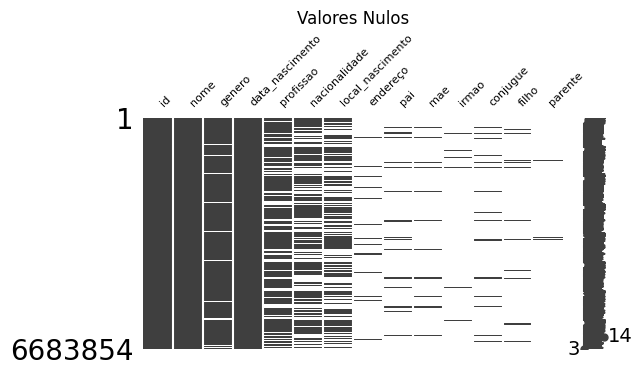

Head do DataFrame Final:


,id,nome,genero,data_nascimento,profissao,nacionalidade,local_nascimento,endereço,pai,mae,irmao,conjugue,filho,parente
0,Q23,george washington,male,1732-02-22,"[politician, farmer, cartographer, geometer, e...","[Kingdom of Great Britain, United States]",[Westmoreland County],"[Philadelphia, Westmoreland County, New York C...",Q768342,Q458119,Q850421;Q7412891;Q6219733;Q5083373;Q75764188;Q...,Q191789,NaN,Q21004273;Q1701323;Q1508559
1,Q42,douglas noel adams,male,1952-03-11,"[playwright, screenwriter, novelist, children'...",[United Kingdom],[Cambridge],"[Cambridge, London, Brentwood, Santa Barbara]",Q14623675,Q14623678,Q14623673,Q14623681,Q14623683,NaN
2,Q1868,paul marie ghislain otlet,male,1868-08-23,"[writer, lawyer, librarian, information scient...",[Belgium],[City of Brussels],[Hôtel Otlet],Q3579983,NaN,Q55824549,NaN,NaN,NaN
3,Q207,george walker bush,male,1946-07-06,"[politician, motivational speaker, autobiograp...",[United States],[New Haven],"[Dallas, George W. Bush Childhood Home]",Q23505,Q190628,Q3305438;Q1375345;Q221997;Q320829;Q52159104,Q152019,Q153730;Q153481,NaN
5,Q368,augusto jose ramon pinochet ugarte,male,1915-11-25,"[military personnel, politician]",[Chile],[Valparaíso],[Valparaíso],NaN,NaN,NaN,Q2287542,Q522106;Q5711719,NaN
6,Q501,charles pierre baudelaire,male,1821-04-09,"[poet, art critic, essayist, translator, write...",[France],"[former 11th arrondissement of Paris, Paris]",[rue d'Amsterdam],Q3184256,Q15973389,NaN,NaN,NaN,NaN
8,Q633,neil percival young,male,1945-11-12,"[singer, singer-songwriter, film director, aut...","[Canada, United States]",[Toronto],"[Omemee, Pickering, Toronto, Winnipeg]",Q1780491,NaN,Q4811453,Q129075052;Q3374257;Q207596,NaN,NaN
9,Q640,harald krichel,male,1969-01-01,"[photographer, Wikimedian]",[Germany],[Hüls],[],NaN,NaN,NaN,Q130343379,NaN,NaN
11,Q815,gabriel gonzalez,male,1898-11-22,"[lawyer, diplomat, politician]",[Chile],[La Serena],[],NaN,NaN,NaN,Q604484,NaN,NaN
12,Q853,andrei arsenyevich tarkovsky,male,1932-04-04,"[film director, actor, film editor, screenwrit...","[Soviet Union, France, Italy]",[Zavrazhye],"[Yuryevets, Moscow, Paris]",Q777997,Q85865549,Q112371293,Q1981049;Q3217941,Q111582472,NaN


In [7]:
# df_clean['telefone_vazio'] = np.nan # coluna telefone vazia

colunas_finais = {
'id': 'id',
'nome': 'nome',
'genero_P21': 'genero',
'nascimento_data_P569': 'data_nascimento',
'ocupacao_P106': 'profissao',
'nacionalidade_P27': 'nacionalidade',
'local_nascimento_P19': 'local_nascimento',
'residencia_P551': 'endereço',
'pai_P22': 'pai',
'mae_P25': 'mae',
'irmaos_P3373': 'irmao',
'conjugue_P26': 'conjugue',
'filhos_P40': 'filho',
'parente_P1038': 'parente'
}

df_final = df_clean.rename(columns=colunas_finais)[list(colunas_finais.values())]
df_grafico = df_final.map(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

df_final.to_csv(output, index=False)

msno.matrix(df_grafico, figsize=(6, 3))
plt.title(f'Valores Nulos')
plt.xticks(fontsize=8)
plt.show()

print("Head do DataFrame Final:")
display(df_final.head(20))